# Métodos de ensamblados 


A pesar de la omnipresencia de los modelos de IA que parecieran ser la mejor herramienta de modelamiento que existe, hay que mencionar que a lo que se refiere a datos tabulares “el estado del arte” siguen siendo los modelos de ensamblados.  En este jupyter notebook haremos una breve  taxonomía de estos métodos y un ejemplo práctico de cada familia.


Sin entrar en definiciones rigurosas , los métodos de ensamblado corresponden a lo que en jerga popular se llama “la opinión de los expertos”. Corresponde a una técnica donde se utilizan varios modelos a la vez. La idea central es generar “diversidad”.Esto en términos generales se logra  ajustando distintos modelos en distintas porciones de los datos. A la hora de predecir se combina la predicción de cada modelo individual.   


# 1. Ensamblados paralelos homogéneos

Corresponden al tipo de ensamblado donde todos los modelos base son del mismo tipo. Como por ejemplo árboles de decisión. Paralelo se refiere a que todos los modelos se entrenan  en forma independiente. Dentro de este grupo podemos encontrar al random forest, bagging , pasting, etc.  En el ejemplo de a continuación implementaremos un random forest.


Los datos utilizados para este ejemplo provienen de kaggle , corresponde a un conjunto sintético , que simula ciertas variables fisiológicas,morfológicas y su impacto en el riesgo de padecer diabetes. Utilizaremos esta última variable como respuesta y crearemos un modelo que nos diga cuales son las variables asociadas a un mayor riesgo.  Una de las ventajas de random forest es que no requiere procesamiento de los atributos.


In [3]:
import kagglehub
import pandas as pd
from sklearn.multiclass import OneVsRestClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelBinarizer 
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, accuracy_score

/home/diego/proyectos/portafolio/ensamblados/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# descomentar la siguiente linea para descargar el dataset, se guardara en la carpeta data
#path = kagglehub.dataset_download("vishardmehta/diabetes-risk-prediction-dataset", output_dir="./data")


In [5]:
df = pd.read_csv("data/diabetes_risk_dataset.csv")
df.head()

,Patient_ID,age,gender,bmi,blood_pressure,fasting_glucose_level,insulin_level,HbA1c_level,cholesterol_level,triglycerides_level,physical_activity_level,daily_calorie_intake,sugar_intake_grams_per_day,sleep_hours,stress_level,family_history_diabetes,waist_circumference_cm,diabetes_risk_score,diabetes_risk_category
0,1,77,Female,33.8,154,93,12.1,5.2,242,194,Low,2169,78.4,8.1,4,No,101.1,52.3,Prediabetes
1,2,54,Male,19.2,123,94,4.6,5.4,212,76,High,1881,16.5,6.6,3,No,60.0,3.7,Low Risk
2,3,25,Male,33.7,141,150,10.8,6.9,247,221,Low,2811,147.9,6.7,10,Yes,114.7,87.3,High Risk
3,4,23,Female,32.8,140,145,11.6,6.8,195,193,Low,2826,98.3,4.4,9,Yes,96.6,76.1,High Risk
4,5,70,Male,33.7,165,90,18.3,5.6,217,170,Moderate,2610,65.8,9.1,5,Yes,107.4,47.7,Prediabetes


Recordemos que estamos en un contexto donde nuestra variable de respuesta,  riesgo diabetico(diabetes_risk_category) presenta 3 categorías (low risk,high risk, prediabetes). Por lo que el problema se enmarca dentro de la categoría de multi etiqueta (multilabel). El enfoque más tradicional para abordar este tipo de problemas es ajustar un modelo para cada etiqueta versus el resto (clasificación binaria). Por ejemplo low risk versus (high risk ,prediabetes), lo que para nuestro caso nos da un total de  3 modelos por separado. La clase OneVsRestClassifier nos permite hacer esto.

In [6]:
X = df.drop(['diabetes_risk_category', 'Patient_ID'], axis=1)
Y = df['diabetes_risk_category']

In [7]:
numericas   = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categoricas = X.select_dtypes(include=['object', 'category']).columns.tolist()

/tmp/ipykernel_2201/3323641831.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoricas = X.select_dtypes(include=['object', 'category']).columns.tolist()


In [8]:
categoricas

['gender', 'physical_activity_level', 'family_history_diabetes']

In [9]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=21)

In [10]:
lb = LabelBinarizer()
Y_train = lb.fit_transform(Y_train)
Y_test = lb.transform(Y_test)

In [11]:
preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(),  categoricas)],remainder='passthrough')

In [12]:
X_train_enc = preprocessor.fit_transform(X_train)  
X_test_enc  = preprocessor.transform(X_test)       

In [13]:
classif = OneVsRestClassifier(RandomForestClassifier(n_estimators=100, random_state=21,n_jobs=4,oob_score=True))

In [14]:
classif.fit(X_train_enc, Y_train)

,"estimator estimator: estimator objectA regressor or a classifier that implements :term:`fit`.When a classifier is passed, :term:`decision_function` will be usedin priority and it will fallback to :term:`predict_proba` if it is notavailable.When a regressor is passed, :term:`predict` is used.",RandomForestC...ndom_state=21)
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation: the `n_classes`one-vs-rest problems are computed in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: 0.20 `n_jobs` default changed from 1 to None",None
,"verbose verbose: int, default=0The verbosity level, if non zero, progress messages are printed.Below 50, the output is sent to stderr. Otherwise, the output is sentto stdout. The frequency of the messages increases with the verbositylevel, reporting all iterations at 10. See :class:`joblib.Parallel` formore details... versionadded:: 1.1",0
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None


In [15]:
# accuracy out-of-bag score de cada clasificador
print(classif.estimators_[0].oob_score_)
print(classif.estimators_[1].oob_score_)
print(classif.estimators_[2].oob_score_)


0.9997916666666666
1.0
0.9995833333333334


In [16]:
y_pred = classif.predict(X_test_enc)

In [17]:
accuracy_score(Y_test, y_pred)

0.9991666666666666

In [18]:
print(classification_report(Y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       430
           1       1.00      1.00      1.00       543
           2       1.00      1.00      1.00       227

   micro avg       1.00      1.00      1.00      1200
   macro avg       1.00      1.00      1.00      1200
weighted avg       1.00      1.00      1.00      1200
 samples avg       1.00      1.00      1.00      1200



/home/diego/proyectos/portafolio/ensamblados/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Los resultados muestran que nuestro modelo tiene un desempeño casi perfecto. Esto se debe a que el dataset es sencillo y las clases son bastante separables

In [19]:

# Feature importances del clasificador de la clase 0
fi_clase_0 = classif.estimators_[0].feature_importances_
# Feature importances del clasificador de la clase 1
fi_clase_1 = classif.estimators_[1].feature_importances_
# Feature importances del clasificador de la clase 2
fi_clase_2 = classif.estimators_[2].feature_importances_



Una funcionalidad atractiva de Random Forest es la entrega de un score, que mide la importancia relativa de la variable en el modelo. Hay que considerar que este score puede tener problemas con las variables que correlacionan.  A continuación un score de las variables con mayor impacto para cada uno de los 3 modelos.


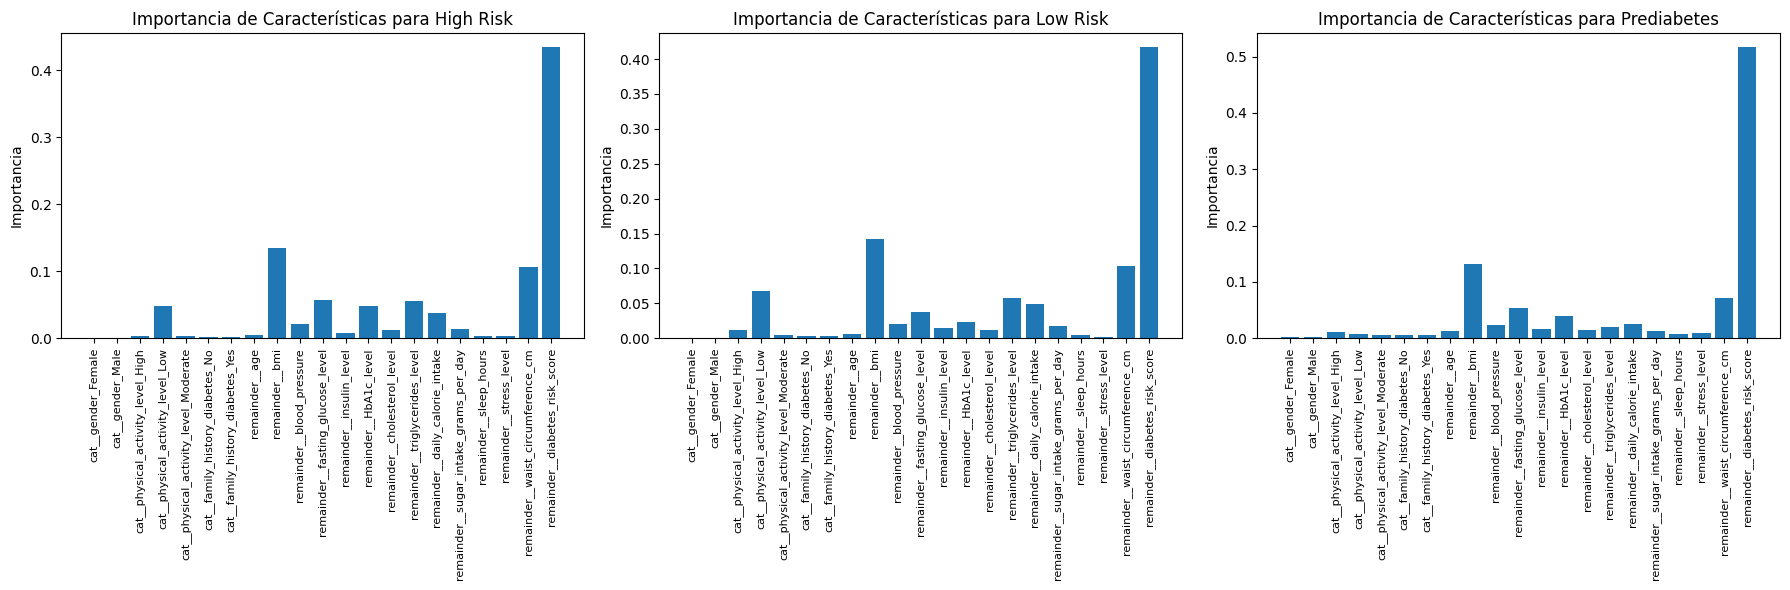

In [20]:
import matplotlib.pyplot as plt

# Obtener los nombres de las características después de la transformación
feature_names = preprocessor.get_feature_names_out()

# Crear una figura con 3 subplots en una fila
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Lista de los vectores de importancia de características
fi_vectors = [fi_clase_0, fi_clase_1, fi_clase_2]
class_names = lb.classes_.tolist()

for i, (fi, class_name) in enumerate(zip(fi_vectors, class_names)):
    axes[i].bar(range(len(fi)), fi)
    axes[i].set_xticks(range(len(fi)))
    axes[i].set_xticklabels(feature_names, rotation=90, fontsize=8)
    axes[i].set_title(f'Importancia de Características para {class_name}')
    axes[i].set_ylabel('Importancia')

plt.tight_layout()
plt.show()

El gráfico es bien decidor , el score de riesgo diabetico es la variable con mayor poder predictivo en los 3 casos, le siguen el índice de masa corporal (BMI) y la circunferencia de la cintura en cm. 


# 2 Ensamblados paralelos heterogéneos 

Para esta parte utilizaremos un famoso dataset sobre la calidad de vinos, que se puede descargar desde https://archive.ics.uci.edu/dataset/186/wine+quality

La única diferencia con los ensamblados paralelos homogéneos es que en este caso los modelos base pueden ser de cualquier tipo. Por ejemplo en un problema de clasificación podemos armar un ensamblado heterogéneo con un modelo de regresión logística, un modelo de vecino más cercano, una red neuronal etc. 

In [51]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import f1_score ,classification_report
# modelos base
from sklearn.linear_model import LogisticRegression
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import StackingClassifier
# modelo meta
from sklearn.neural_network import MLPClassifier

In [22]:
# descargar el dataset en tu directorio local y ejecuta el siguiente comando para descomprimirlo en la carpeta data/ensemble_parallel_heterogeneous/
#!unzip wine+quality.zip -d data/ensemble_parallel_heterogeneous/

In [23]:
df_red_wine = pd.read_csv("data/ensemble_parallel_heterogeneous/winequality-red.csv", sep=';')
df_white_wine = pd.read_csv("data/ensemble_parallel_heterogeneous/winequality-white.csv", sep=';')

In [24]:
df_white_wine.head()  

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [25]:
# unimos ambos datasets en uno solo
df_wines = pd.concat([df_red_wine, df_white_wine], ignore_index=True)

In [26]:
# agrupamos la variable 'quality' en 3 categorias: 'malo' (0-4), 'normal' (5-6) y 'excelente' (7-10)
df_wines['quality_grouped'] = df_wines['quality'].apply(lambda x: 'malo' if x <= 4 else ('normal' if 5 <= x <= 6 else 'excelente'))

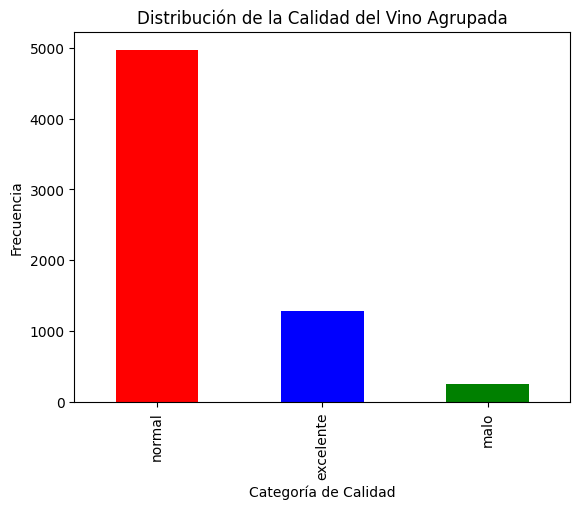

In [27]:
import matplotlib.pyplot as plt

# Plot the distribution of the 'quality_grouped' variable
df_wines['quality_grouped'].value_counts().plot(kind='bar', color=['red', 'blue', 'green'])
plt.title('Distribución de la Calidad del Vino Agrupada')
plt.xlabel('Categoría de Calidad')
plt.ylabel('Frecuencia')
plt.show()

Como se aprecia claramente en el gráfico, nos enfrentamos a un problema de desbalance de clases. Para abordar este problema existen 2 formas principales.Utilizando técnicas de remuestreo y la otra es mediante la modificación del algoritmo, en nuestro caso utilizaremos esta última, ya que es la práctica estándar y en scikit es muy sencillo implementarla.

In [28]:
X = df_wines.drop(['quality', 'quality_grouped'], axis=1)
Y = df_wines['quality_grouped']

In [29]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=21)

In [34]:
modelos_base = [
    ('Logistic Regression', LogisticRegression( random_state=33,class_weight='balanced')),
    ('Gaussian Process', GaussianProcessClassifier(random_state=33)),
    ('K-Nearest Neighbors', KNeighborsClassifier(n_neighbors=5)),
    ('Support Vector Machine', SVC(kernel='rbf', probability=True, random_state=33,class_weight='balanced')),
    ('Decision Tree', DecisionTreeClassifier(random_state=33,class_weight='balanced'))
]

In [40]:
meta_model = MLPClassifier(hidden_layer_sizes=(128,64,32),random_state=33, max_iter=500)

El stacking es un tipo de ensamblado donde se entrena un conjunto de modelos base y se utiliza las predicciones de estos(probabilidad y/o etiqueta) como input para entrenar un meta-modelo (en nuestro caso una red neuronal). en scikit-learn la clase stackinClassifier nos permite realizar esto de forma simple.   

In [43]:
clf = StackingClassifier(
    estimators=modelos_base, final_estimator=meta_model)


In [44]:
pipe = make_pipeline(StandardScaler(), clf)

In [45]:
pipe.fit(X_train, Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('stackingclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('Logistic Regression', ...), ('Gaussian Process', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",MLPClassifier...ndom_state=33)
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the sp

In [53]:
print(classification_report(Y_test, pipe.predict(X_test)))

              precision    recall  f1-score   support

   excelente       0.74      0.43      0.54       256
        malo       0.18      0.04      0.07        49
      normal       0.83      0.96      0.89       995

    accuracy                           0.82      1300
   macro avg       0.59      0.48      0.50      1300
weighted avg       0.79      0.82      0.79      1300



In [ ]:
X_train_scaled = pipe.named_steps['standardscaler'].transform(X_train)
X_test_scaled = pipe.named_steps['standardscaler'].transform(X_test)

for nombre, modelo in modelos_base:
    print(f"Entrenando modelo base: {nombre}")
    modelo.fit(X_train_scaled, Y_train)
    y_pred_base = modelo.predict(X_test_scaled)
    print(classification_report(Y_test, y_pred_base)) 

Entrenando modelo base: Logistic Regression
Accuracy del modelo base Logistic Regression: 0.6208
Entrenando modelo base: Gaussian Process


/home/diego/proyectos/portafolio/ensamblados/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/diego/proyectos/portafolio/ensamblados/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
   

Accuracy del modelo base Gaussian Process: 0.7831
Entrenando modelo base: K-Nearest Neighbors
Accuracy del modelo base K-Nearest Neighbors: 0.7492
Entrenando modelo base: Support Vector Machine
Accuracy del modelo base Support Vector Machine: 0.4800
Entrenando modelo base: Decision Tree
Accuracy del modelo base Decision Tree: 0.7500
